# Turbofan Engine Remaining Useful Life Prediction

## 0. Training and Test Data: 
The three files used in this project serve different purposes:

**train_FD001.txt**

Contains complete run-to-failure trajectories. Each engine is observed
from the beginning of its recorded operation until failure. Therefore,
the RUL for every training observation can be calculated from the
engine's final cycle.

**test_FD001.txt**

Contains partial engine trajectories. Each engine's observations stop
before failure, so its failure cycle cannot be determined directly from
this file.

**RUL_FD001.txt**

Contains the true Remaining Useful Life for each test engine after its
final observed cycle. These values are used to evaluate predictions on
the official FD001 test set.

## 1. Problem Statement

Predict the Remaining Useful Life (RUL) of turbofan engines using
time-series sensor measurements from NASA's C-MAPSS FD001 dataset.

Each engine begins operation in a healthy state and is monitored over
successive operating cycles. The training trajectories continue until
failure.

The goal is to use operating conditions and sensor measurements to
estimate how many operating cycles an engine has remaining before failure.

## 2. Importing the libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Loading the dataset: 
Since our raw files don't contain column headers, we have to create them ourselves. 

In [5]:
# Making the columns headers: 
index_columns = ["engine_id", "cycle"]

setting_columns = ["setting_1", "setting_2", "setting_3"]

sensor_columns = [
    f"sensor_{i}" for i in range(1, 22)
]

columns = index_columns + setting_columns + sensor_columns

And now we can read the files YAYYY!

In [10]:
# Note: The header parameter identifies which row(s) 
# should be used as the DataFrame column names. 
# header=None Tells Pandas the file has no column names.

train_df = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    "data/test_FD001.txt", 
    sep=r"\s+",
    header=None, 
    names=columns
)

rul_df = pd.read_csv(
    "data/RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 4. Dataset Information: 


### Shape and number of engines:

In [13]:
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

## Number of engines:
print()
print("Training engines:", train_df["engine_id"].nunique())
print("Test engines:", test_df["engine_id"].nunique())

Training shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)

Training engines: 100
Test engines: 100


### Basic information:

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

### Dataset Structure

The dataset consists of multivariate time-series measurements. Each
row represents a snapshot of one engine during a single operating cycle.

The raw data contains 26 columns:

1. Engine/unit number
2. Time in operating cycles
3. Operational setting 1
4. Operational setting 2
5. Operational setting 3
6–26. Sensor measurements 1–21

The operational settings affect engine performance, while the sensor
measurements contain noisy observations of the engine's condition over
time.

## 5. Data Quality Checks:

### Missing Data: 

In [ ]:
train_df.isnull().sum()

In [ ]:
test_df.isnull().sum()

This means that we ahev no missing data!

### Duplicates:

In [19]:
print(f"we have {train_df.duplicated().sum()} duplicates in training data")
print(f"we have {test_df.duplicated().sum()} duplicates in testing data")

we have 0 duplicates in training data
we have 0 duplicates in testing data


## 6. Statical Summeries

In [20]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [21]:
train_df.nunique().sort_values()

sensor_19       1
sensor_18       1
setting_3       1
sensor_1        1
sensor_16       1
sensor_5        1
sensor_10       1
sensor_6        2
setting_2      13
sensor_17      13
sensor_8       53
sensor_13      56
engine_id     100
sensor_20     120
setting_1     158
sensor_11     159
sensor_2      310
cycle         362
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

This means that some of the settings/sensores are essentially constant in FD001. They are: 
* setting_3
* sensor_1
* sensor_5
* sensor_10
* sensor_16
* sensor_18
* sensor_19

## 7. Create the RUL Target
So in order to find the remaining useful life, we have to take the highest number of cycles taken by that engine before failiure, and minus it by the current cycle number. 

For Example: 
* Let's say engine 1 goes 113 total of cycles. And right now we are in cycle 13. So the remaining useful life would be 113 - 13 = 100. 

In [29]:
max_cycles = train_df.groupby("engine_id")["cycle"].max()
print(max_cycles.head())

train_df["RUL"] = (
    train_df["engine_id"].map(max_cycles) 
    - train_df["cycle"]
) 

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64


## 8. Analyze Engine Lifetimes

Now we start doing EDA that is specific to your project.

In [30]:
engine_lifetimes = (
    train_df.groupby("engine_id")["cycle"]
    .max()
)

engine_lifetimes.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Your 100 training engines have observed lifetimes ranging from 128 to 362 cycles, with an average of about 206 cycles.

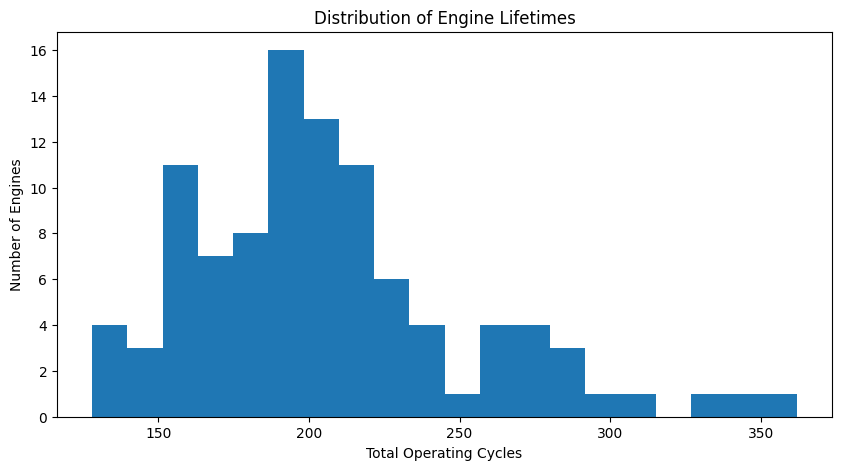

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(engine_lifetimes, bins=20)

plt.xlabel("Total Operating Cycles")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")

plt.show()

This plot explains that how many of our engines had x number of cycles. 

For example: 
* we had about 16 engines that had a total of 200 cycles. 
* we had only 1 engine that had 350 cycles. 

## 9. Sensor Variability Analysis: 
We want to distinguish between: 
* **constant sensors → probably useless**
* **changing sensors → potentially useful degradation signals**

We find the variance of the sensors, and the higher the variance is, the more change it had through the data. So if a sensor has a variance of 0, it means it has not changed at all and it's been constant. 

In [32]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

sensor_variance = train_df[sensor_cols].var().sort_values()

sensor_variance

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    1.926023e-34
sensor_5     3.155597e-30
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64

## 10. Sensor Degradation Over Time

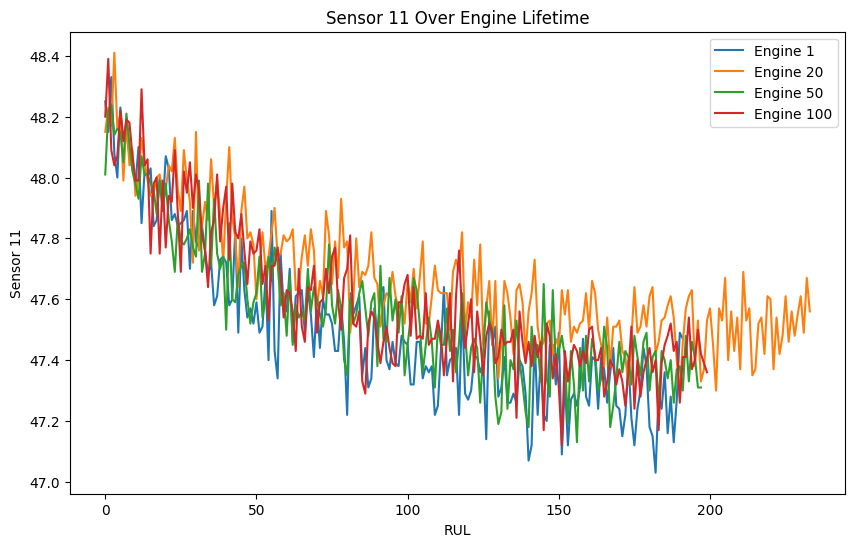

In [38]:
# Pick several engines: 
engine_ids = [1, 20, 50, 100]

# Then examine an informative sensor over its lifetime:

plt.figure(figsize=(10, 6))

for engine_id in engine_ids:
    engine_data = train_df[
        train_df["engine_id"] == engine_id
    ]

    plt.plot(
        engine_data["RUL"],
        engine_data["sensor_11"],
        label=f"Engine {engine_id}"
    )

plt.xlabel("RUL")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Over Engine Lifetime")
plt.legend()
plt.show()

Sensor 11 demonstrates a clear relationship with engine degradation across the selected engines. As RUL decreases and the engines approach failure, Sensor 11 measurements generally increase. Although individual measurements fluctuate due to sensor noise, a similar overall trend appears across multiple engines, suggesting that Sensor 11 may be informative for RUL prediction.

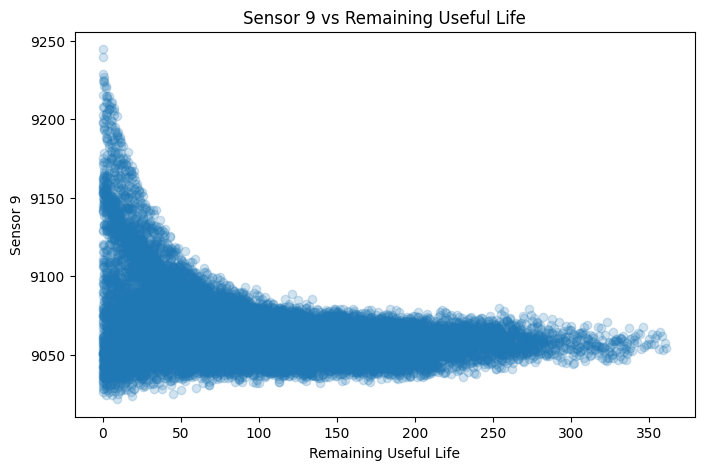

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    train_df["RUL"],
    train_df["sensor_9"],
    alpha=0.2
)

plt.xlabel("Remaining Useful Life")
plt.ylabel("Sensor 9")
plt.title("Sensor 9 vs Remaining Useful Life")

plt.show()

Sensor 9 shows a noticeable relationship with RUL. At higher RUL values, measurements are relatively concentrated, while lower RUL values are associated with greater variability and higher sensor measurements. This suggests Sensor 9 may contain useful information about engine degradation.

## 11. Correlation With RUL
This helps us identify which individual sensors have stronger linear relationships with degradation, while remembering that low simple correlation does not automatically mean a feature is useless to a nonlinear/time-series model.

In [40]:
correlations = (
    train_df[sensor_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

correlations

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

## 12. Correlation Between Sensors
Then we can investigate redundant sensors.

In [44]:
corr_matrix = train_df[sensor_cols].corr()
corr_matrix.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
sensor_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensor_2,NaN,1.000000,0.602610,0.714949,NaN,0.132242,-0.702136,0.662325,0.273764,NaN,...,-0.724578,0.661792,0.179752,0.675975,NaN,0.629886,NaN,NaN,-0.661841,-0.668050
sensor_3,NaN,0.602610,1.000000,0.678413,NaN,0.116039,-0.664595,0.602481,0.322964,NaN,...,-0.680307,0.600963,0.237137,0.639921,NaN,0.600017,NaN,NaN,-0.625941,-0.633901
sensor_4,NaN,0.714949,0.678413,1.000000,NaN,0.150480,-0.793130,0.746852,0.297429,NaN,...,-0.815591,0.745158,0.190748,0.758459,NaN,0.703499,NaN,NaN,-0.748067,-0.745193
sensor_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Compare Early-Life vs Near-Failure Sensor Behavior
* Which sensors noticeably change as engines approach failure?

In [48]:
early_life = train_df[train_df["RUL"] > 150]
near_failure = train_df[train_df["RUL"] < 30]
# Now we ahve datas that has appeared to do poorly and 
# the ones that did good. 

## 14. EDA Conclusions
The FD001 training dataset contains 100 engine run-to-failure
trajectories and 20,631 cycle-level observations.

Key observations:

- The dataset contains no missing values.
- Each engine has a different operating lifetime.
- Several sensors are constant or nearly constant and therefore
  provide little useful predictive information.
- Several sensor measurements exhibit degradation trends as engines
  approach failure.
- Sensor measurements are time-dependent, meaning observations from
  the same engine cannot be treated as independent samples.
- RUL can be calculated for the training data using each engine's
  final operating cycle.
- Feature engineering based on sensor trends and rolling statistics
  may capture degradation better than individual cycle measurements.